# TIMMD — 02: Estilo de Juego

Caracteriza a cada equipo según su forma de jugar en el partido analizado. Calcula métricas sobre posesión, verticalidad, vocación ofensiva, presión, agresividad y solidez defensiva. Los resultados se presentan como un radar chart comparativo, una tabla de métricas brutas y una etiqueta de estilo generada automáticamente (posesionista, directo, ofensivo, etc.).

## 1. Configuración y carga de datos

Monta Google Drive, carga los eventos del partido y define los equipos.
El único valor a modificar entre partidos es `MATCH_ID`.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

# Si no tenés acceso: abrí este link y elegí 'Agregar acceso directo a Mi unidad' con el nombre TIMMD
# https://drive.google.com/drive/folders/1JCn2VRcg4vnjB5G0cq40gpGMgddG1PQR
DATA_DIR = "/content/drive/MyDrive/TIMMD/data"
MATCH_ID = 3895153            # ← único valor a cambiar entre partidos

eventos   = pd.read_parquet(f"{DATA_DIR}/eventos_{MATCH_ID}.parquet")
lineup_df = pd.read_parquet(f"{DATA_DIR}/lineups_{MATCH_ID}.parquet")

equipos      = eventos["team"].dropna().unique().tolist()
equipo_local = equipos[0]
equipo_visit = equipos[1]

print(f"✓ Partido {MATCH_ID} cargado — {eventos.shape[0]} eventos")
print(f"  {equipo_local} vs {equipo_visit}")

Mounted at /content/drive
✓ Partido 3895153 cargado — 4520 eventos
  Werder Bremen vs Bayer Leverkusen


## 2. Colores de equipo

Carga el diccionario de colores oficiales por equipo desde el archivo compartido en Drive.
Si un equipo no está en el diccionario, se usa un gris por defecto.

In [3]:
import sys
sys.path.append("/content/drive/MyDrive/TIMMD")
from colores_equipos import get_color

color_local = get_color(equipo_local)
color_visit = get_color(equipo_visit)

print(f"{equipo_local} → {color_local}")
print(f"{equipo_visit} → {color_visit}")

Werder Bremen → #1D9052
Bayer Leverkusen → #E32221


## 3. Cálculo de métricas por equipo

Para cada equipo extrae las métricas brutas de los 6 ejes de análisis desde los eventos del partido.
Se excluyen los penales (period 5) para no distorsionar los promedios de juego abierto.

In [4]:
ev       = eventos[eventos["period"] < 5].copy()
metricas = {}

for equipo in [equipo_local, equipo_visit]:
    eq          = ev[ev["team"] == equipo]
    total_pases = ev[ev["type"] == "Pass"].shape[0]

    pases         = eq[eq["type"] == "Pass"]
    tiros         = eq[eq["type"] == "Shot"]
    carries       = eq[eq["type"] == "Carry"]
    presiones     = eq[eq["type"] == "Pressure"]
    duelos        = eq[eq["type"] == "Duel"]
    faltas        = eq[eq["type"] == "Foul Committed"]
    intercepciones = eq[eq["type"] == "Interception"]
    despejes      = eq[eq["type"] == "Clearance"]
    bloqueos      = eq[eq["type"] == "Block"]
    recuperaciones = eq[eq["type"] == "Ball Recovery"]

    # 1. POSESIÓN
    posesion_pct = len(pases) / total_pases * 100 if total_pases > 0 else 50

    # 2. VERTICALIDAD
    largo_promedio  = pases["pass_length"].mean() if "pass_length" in pases.columns else 0
    pases_altos     = pases[pases["pass_height"] == "High Pass"].shape[0]
    pct_pases_altos = pases_altos / len(pases) * 100 if len(pases) > 0 else 0

    # 3. VOCACIÓN OFENSIVA
    n_tiros  = len(tiros)
    xg_total = tiros["shot_statsbomb_xg"].sum() if "shot_statsbomb_xg" in tiros.columns else 0
    carries_ataque = 0
    if "carry_end_location" in carries.columns:
        carries_ataque = carries["carry_end_location"].apply(
            lambda loc: loc[0] > 80 if hasattr(loc, '__len__') and len(loc) >= 1 else False
        ).sum()

    # 4. PRESIÓN
    n_presiones      = len(presiones)
    acciones_def     = pd.concat([presiones, recuperaciones])
    altura_recuperacion = acciones_def["location"].dropna().apply(
        lambda loc: loc[0] if hasattr(loc, '__len__') and len(loc) >= 1 else None
    ).mean()

    # 5. AGRESIVIDAD
    agresividad = len(duelos) + len(faltas) * 2

    # 6. SOLIDEZ DEFENSIVA
    solidez = len(intercepciones) + len(despejes) + len(bloqueos) + len(recuperaciones)

    metricas[equipo] = {
        "posesion_pct":        round(posesion_pct, 1),
        "largo_pase_promedio": round(largo_promedio, 1),
        "pct_pases_altos":     round(pct_pases_altos, 1),
        "n_tiros":             n_tiros,
        "xg_total":            round(float(xg_total), 2),
        "carries_ataque":      int(carries_ataque),
        "n_presiones":         n_presiones,
        "altura_recuperacion": round(float(altura_recuperacion), 1) if altura_recuperacion else 0,
        "agresividad":         agresividad,
        "solidez":             solidez,
    }

m_local = metricas[equipo_local]
m_visit = metricas[equipo_visit]

print(pd.DataFrame(metricas).T.to_string())

                  posesion_pct  largo_pase_promedio  pct_pases_altos  n_tiros  xg_total  carries_ataque  n_presiones  altura_recuperacion  agresividad  solidez
Werder Bremen             41.0                 20.5             16.0      2.0      0.19            85.0        210.0                 61.3         59.0    107.0
Bayer Leverkusen          59.0                 16.9             11.3     14.0      1.09           142.0        206.0                 61.3         36.0     90.0


## 4. Normalización para el radar

Convierte cada métrica a un score 0-100 relativo entre los dos equipos del partido.
Cada eje combina varias métricas ponderadas antes de normalizar.

In [5]:
def norm_relativa(val_a, val_b):
    total = val_a + val_b
    if total == 0:
        return 50, 50
    return round(val_a / total * 100, 1), round(val_b / total * 100, 1)

ejes = {}

# 1. Posesión
ejes["Posesión"] = (m_local["posesion_pct"], m_visit["posesion_pct"])

# 2. Verticalidad — largo de pase + % pases altos
ejes["Verticalidad"] = norm_relativa(
    m_local["largo_pase_promedio"] + m_local["pct_pases_altos"] * 2,
    m_visit["largo_pase_promedio"] + m_visit["pct_pases_altos"] * 2
)

# 3. Vocación ofensiva — tiros + xG + carries al ataque
ejes["Vocación\nofensiva"] = norm_relativa(
    m_local["n_tiros"] * 2 + m_local["xg_total"] * 10 + m_local["carries_ataque"],
    m_visit["n_tiros"] * 2 + m_visit["xg_total"] * 10 + m_visit["carries_ataque"]
)

# 4. Presión — cantidad + altura de recuperación
ejes["Presión"] = norm_relativa(
    m_local["n_presiones"] + m_local["altura_recuperacion"],
    m_visit["n_presiones"] + m_visit["altura_recuperacion"]
)

# 5. Agresividad
ejes["Agresividad"] = norm_relativa(m_local["agresividad"], m_visit["agresividad"])

# 6. Solidez defensiva
ejes["Solidez\ndefensiva"] = norm_relativa(m_local["solidez"], m_visit["solidez"])

## 5. Radar chart — Perfil de estilo

Visualiza los 6 ejes como un radar chart comparativo entre los dos equipos.
Una línea punteada en 50 marca el punto de equilibrio entre ambos.

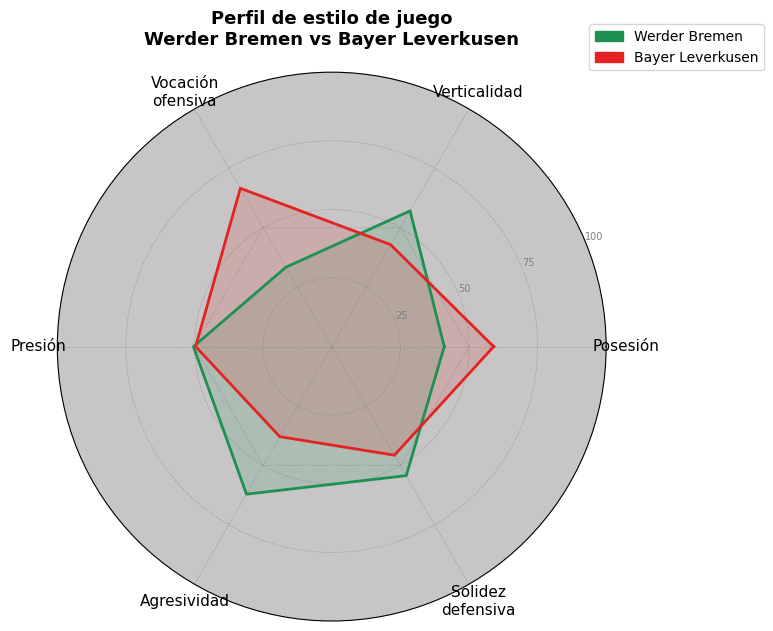

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels       = list(ejes.keys())
scores_local = [ejes[e][0] for e in labels]
scores_visit = [ejes[e][1] for e in labels]

N      = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

# Cerrar el polígono
scores_local += scores_local[:1]
scores_visit += scores_visit[:1]
angles       += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, scores_local, color=color_local, linewidth=2)
ax.fill(angles, scores_local, color=color_local, alpha=0.15)
ax.plot(angles, scores_visit, color=color_visit, linewidth=2)
ax.fill(angles, scores_visit, color=color_visit, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25", "50", "75", "100"], fontsize=7, color="gray")
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.5)
ax.plot(angles, [50] * len(angles), color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
ax.set_facecolor('#c7c5c5')

patch_local = mpatches.Patch(color=color_local, label=equipo_local)
patch_visit = mpatches.Patch(color=color_visit, label=equipo_visit)
ax.legend(handles=[patch_local, patch_visit], loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.set_title(f"Perfil de estilo de juego\n{equipo_local} vs {equipo_visit}",
             fontsize=13, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

## 6. Tabla comparativa

Muestra las métricas brutas de ambos equipos lado a lado para facilitar la comparación numérica.
Complementa el radar con los valores exactos detrás de cada eje.

In [7]:
tabla = pd.DataFrame({
    "Métrica": [
        "Posesión (%)", "Largo pase promedio (m)", "Pases altos (%)",
        "Tiros", "xG total", "Carries zona ataque",
        "Presiones", "Altura recuperación (x)",
        "Agresividad (score)", "Solidez defensiva (score)",
    ],
    equipo_local: [
        m_local["posesion_pct"], m_local["largo_pase_promedio"], m_local["pct_pases_altos"],
        m_local["n_tiros"], m_local["xg_total"], m_local["carries_ataque"],
        m_local["n_presiones"], m_local["altura_recuperacion"],
        m_local["agresividad"], m_local["solidez"],
    ],
    equipo_visit: [
        m_visit["posesion_pct"], m_visit["largo_pase_promedio"], m_visit["pct_pases_altos"],
        m_visit["n_tiros"], m_visit["xg_total"], m_visit["carries_ataque"],
        m_visit["n_presiones"], m_visit["altura_recuperacion"],
        m_visit["agresividad"], m_visit["solidez"],
    ]
})

print(tabla.to_string(index=False))

                  Métrica  Werder Bremen  Bayer Leverkusen
             Posesión (%)          41.00             59.00
  Largo pase promedio (m)          20.50             16.90
          Pases altos (%)          16.00             11.30
                    Tiros           2.00             14.00
                 xG total           0.19              1.09
      Carries zona ataque          85.00            142.00
                Presiones         210.00            206.00
  Altura recuperación (x)          61.30             61.30
      Agresividad (score)          59.00             36.00
Solidez defensiva (score)         107.00             90.00


## 7. Etiqueta de estilo automática

Asigna etiquetas descriptivas a cada equipo comparando sus métricas contra las del rival.
Las etiquetas son acumulativas — un equipo puede ser posesionista y ofensivo al mismo tiempo.

In [8]:
def etiqueta_estilo(m, m_rival):
    etiquetas = []

    if m["posesion_pct"] > 55:
        etiquetas.append("Posesionista")
    elif m["posesion_pct"] < 45:
        etiquetas.append("Cedió la pelota")

    if m["pct_pases_altos"] > m_rival["pct_pases_altos"] * 1.3:
        etiquetas.append("Juego directo")
    elif m["largo_pase_promedio"] < m_rival["largo_pase_promedio"] * 0.9:
        etiquetas.append("Juego corto")

    if m["xg_total"] > 1.5:
        etiquetas.append("Muy ofensivo")
    elif m["n_tiros"] > m_rival["n_tiros"] * 1.3:
        etiquetas.append("Ofensivo")

    if m["n_presiones"] > m_rival["n_presiones"] * 1.2:
        etiquetas.append("Presión alta")

    if m["solidez"] > m_rival["solidez"] * 1.2:
        etiquetas.append("Sólido defensivamente")

    if m["agresividad"] > m_rival["agresividad"] * 1.3:
        etiquetas.append("Físico / agresivo")

    return etiquetas if etiquetas else ["Equilibrado"]

et_local = etiqueta_estilo(m_local, m_visit)
et_visit = etiqueta_estilo(m_visit, m_local)

print(f"\n{'='*40}")
print(f"  {equipo_local}")
print(f"  → {' · '.join(et_local)}")
print(f"{'='*40}")
print(f"  {equipo_visit}")
print(f"  → {' · '.join(et_visit)}")
print(f"{'='*40}")


  Werder Bremen
  → Cedió la pelota · Juego directo · Físico / agresivo
  Bayer Leverkusen
  → Posesionista · Juego corto · Ofensivo
